In [46]:
from surya.layout import LayoutPredictor
from surya.recognition import RecognitionPredictor
from surya.foundation import FoundationPredictor
from surya.detection import DetectionPredictor
from surya.settings import settings
from PIL import Image

lfp = FoundationPredictor(checkpoint=settings.LAYOUT_MODEL_CHECKPOINT)
lp = LayoutPredictor(lfp)

rfp = FoundationPredictor(checkpoint=settings.RECOGNITION_MODEL_CHECKPOINT)
rp = RecognitionPredictor(rfp)

dp = DetectionPredictor(checkpoint=settings.DETECTOR_MODEL_CHECKPOINT)

In [10]:
pdf_path = 'rlbook2020.pdf'
from pathlib import Path
Path(pdf_path).exists()

True

In [11]:
import torch
print(torch.cuda.is_available())

True


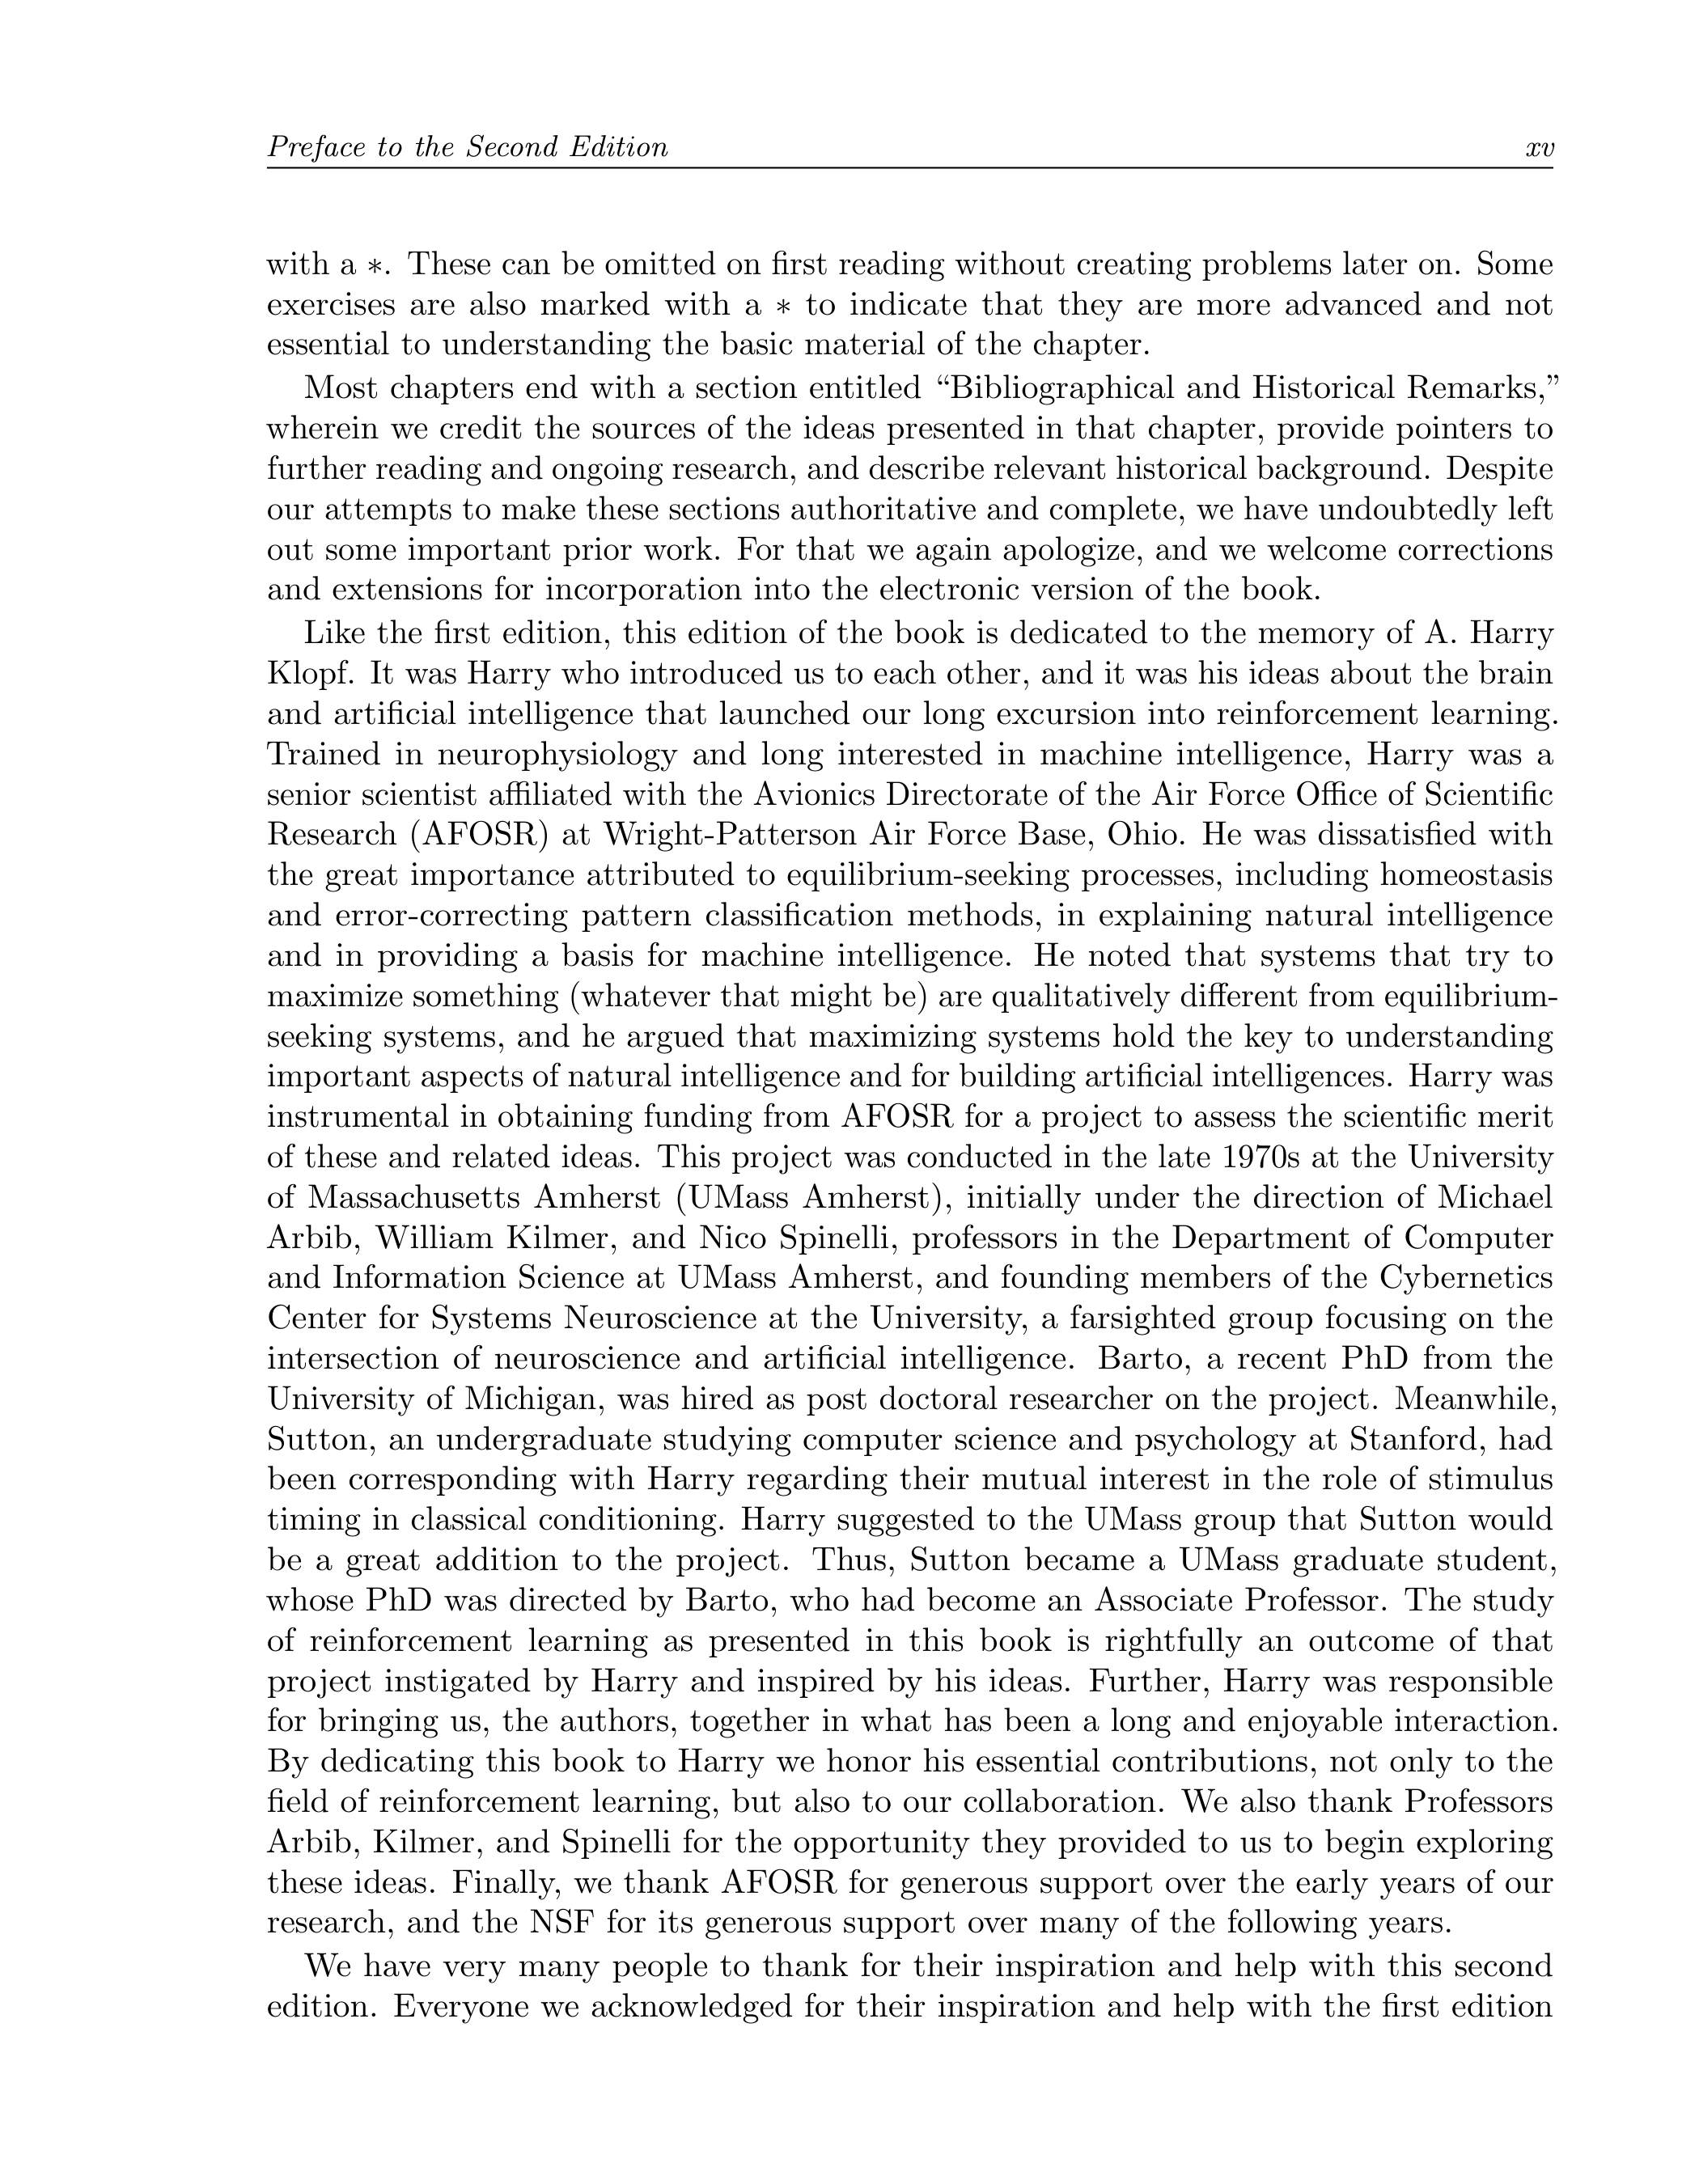

In [12]:
import fitz
from PIL import Image
import io

doc = fitz.open(pdf_path)
page = doc[14]
pix = page.get_pixmap(dpi=300)
img = Image.open(io.BytesIO(pix.tobytes("png")))

img

In [18]:
import rich

In [15]:
layout_results = lp([img.convert("RGB")])

Recognizing Layout: 100%|██████████| 1/1 [00:00<00:00,  3.74it/s]


In [19]:
rich.print(layout_results)

[
    LayoutResult(
        bboxes=[
            LayoutBox(
                polygon=[
                    [326.07421875, 164.794921875],
                    [822.36328125, 164.794921875],
                    [822.36328125, 199.072265625],
                    [326.07421875, 199.072265625]
                ],
                confidence=0.9983155727386475,
                label='PageHeader',
                position=0,
                top_k={
                    'PageHeader': 0.9983155727386475,
                    'Text': 0.0016484236111864448,
                    'SectionHeader': 8.383995918848086e-06,
                    'Caption': 5.5849459386081435e-06,
                    'Picture': 4.282126610632986e-06
                },
                bbox=[326.07421875, 164.794921875, 822.36328125, 199.072265625]
            ),
            LayoutBox(
                polygon=[
                    [1883.642578125, 167.431640625],
                    [1922.607421875, 167.431640625],
                    [1922.607421875, 191.162109375],
                    [1883.642578125, 191.162109375]
                ],
                confidence=0.9942985773086548,
                label='PageHeader',
                position=1,
                top_k={
                    'PageHeader': 0.9942985773086548,
                    'Text': 0.005554107017815113,
                    'SectionHeader': 8.701172191649675e-05,
                    'Caption': 3.407428084756248e-05,
                    'Picture': 9.315389434050303e-06
                },
                bbox=[1883.642578125, 167.431640625, 1922.607421875, 191.162109375]
            ),
            LayoutBox(
                polygon=[
                    [328.125, 308.49609375],
                    [1919.53125, 308.49609375],
                    [1919.53125, 445.60546875],
                    [328.125, 445.60546875]
                ],
                confidence=0.9994530081748962,
                label='Text',
                position=2,
                top_k={
                    'Text': 0.9994530081748962,
                    'Caption': 0.0003569027758203447,
                    'SectionHeader': 9.910832159221172e-05,
                    'PageHeader': 6.811608182033524e-05,
                    'Picture': 1.0947251212201081e-05
                },
                bbox=[328.125, 308.49609375, 1919.53125, 445.60546875]
            ),
            LayoutBox(
                polygon=[
                    [328.125, 454.833984375],
                    [1919.53125, 454.833984375],
                    [1919.53125, 747.509765625],
                    [328.125, 747.509765625]
                ],
                confidence=0.999971866607666,
                label='Text',
                position=3,
                top_k={
                    'Text': 0.999971866607666,
                    'PageHeader': 5.3380340432340745e-06,
                    'Caption': 5.014619091525674e-06,
                    'ListItem': 5.014619091525674e-06,
                    'SectionHeader': 4.356776116765104e-06
                },
                bbox=[328.125, 454.833984375, 1919.53125, 747.509765625]
            ),
            LayoutBox(
                polygon=[
                    [324.0234375, 754.1015625],
                    [1923.6328125, 754.1015625],
                    [1923.6328125, 2388.8671875],
                    [324.0234375, 2388.8671875]
                ],
                confidence=0.999987006187439,
                label='Text',
                position=4,
                top_k={
                    'Text': 0.999987006187439,
                    'SectionHeader': 4.710869689006358e-06,
                    'ListItem': 2.521547003198066e-06,
                    'Footnote': 1.026787685987074e-06,
                    'Picture': 9.721428568809642e-07
                },
                bbox=[324.0234375, 754.1015625, 1923.6328125, 2388.8671875]
            ),
            LayoutBox(
                polygon=[
                    [3

In [34]:
boxes = layout_results[0].bboxes

In [35]:
boxes

[LayoutBox(polygon=[[326.07421875, 164.794921875], [822.36328125, 164.794921875], [822.36328125, 199.072265625], [326.07421875, 199.072265625]], confidence=0.9983155727386475, label='PageHeader', position=0, top_k={'PageHeader': 0.9983155727386475, 'Text': 0.0016484236111864448, 'SectionHeader': 8.383995918848086e-06, 'Caption': 5.5849459386081435e-06, 'Picture': 4.282126610632986e-06}, bbox=[326.07421875, 164.794921875, 822.36328125, 199.072265625]),
 LayoutBox(polygon=[[1883.642578125, 167.431640625], [1922.607421875, 167.431640625], [1922.607421875, 191.162109375], [1883.642578125, 191.162109375]], confidence=0.9942985773086548, label='PageHeader', position=1, top_k={'PageHeader': 0.9942985773086548, 'Text': 0.005554107017815113, 'SectionHeader': 8.701172191649675e-05, 'Caption': 3.407428084756248e-05, 'Picture': 9.315389434050303e-06}, bbox=[1883.642578125, 167.431640625, 1922.607421875, 191.162109375]),
 LayoutBox(polygon=[[328.125, 308.49609375], [1919.53125, 308.49609375], [1919

In [36]:
bboxes = [box.bbox for box in boxes]

In [54]:
rp_result = rp([img], bboxes=[bboxes], sort_lines=True, math_mode=True)

Recognizing Text: 100%|██████████| 6/6 [00:02<00:00,  2.94it/s]


In [55]:
rich.print([text_line.text for text_line in rp_result[0].text_lines])

[
    'Preface to the Second Edition',
    'xv',
    'with a *. These can be omitted on first reading without creating problems later on. Some exercises are also 
marked with a * to indicate that they are more advanced and not essential to understanding the basic material of 
t',
    'Most chapters end with a section entitled "Bibliographical and Historical Remarks," wherein we credit the 
sources of the ideas presented in that chapter, provide pointers to further reading and ongoing research, and 
descri',
    'Like the first edition, this edition of the book is dedicated to the memory of A. Harry Klopf. It was Harry 
who introduced us to each other, and it was his ideas about the brain and artificial intelligence that launched 
ou',
    'We have very many people to thank for their inspiration and help with this second<br>edition. Everyone we 
acknowledged for their inspiration and help with the first edition'
]

In [47]:
rp_result = rp([img], det_predictor=dp, sort_lines=True, math_mode=True)

Recognizing Text: 100%|██████████| 46/46 [00:01<00:00, 26.75it/s]


In [49]:
lines = [text_line.text for text_line in rp_result[0].text_lines]

In [50]:
len(lines)

46

In [51]:
rich.print(lines)

[
    'Preface to the Second Edition',
    'xv',
    'with a *. These can be omitted on first reading without creating problems later on. Some',
    'exercises are also marked with a * to indicate that they are more advanced and not',
    'essential to understanding the basic material of the chapter.',
    'Most chapters end with a section entitled "Bibliographical and Historical Remarks,"',
    'wherein we credit the sources of the ideas presented in that chapter, provide pointers to',
    'further reading and ongoing research, and describe relevant historical background. Despite',
    'our attempts to make these sections authoritative and complete, we have undoubtedly left',
    'out some important prior work. For that we again apologize, and we welcome corrections',
    'and extensions for incorporation into the electronic version of the book.',
    'Like the first edition, this edition of the book is dedicated to the memory of A. Harry',
    'Klopf. It was Harry who introduced us to each other, and it was his ideas about the brain',
    'and artificial intelligence that launched our long excursion into reinforcement learning.',
    'Trained in neurophysiology and long interested in machine intelligence, Harry was a',
    'senior scientist affiliated with the Avionics Directorate of the Air Force Office of Scientific',
    'Research (AFOSR) at Wright-Patterson Air Force Base, Ohio. He was dissatisfied with',
    'the great importance attributed to equilibrium-seeking processes, including homeostasis',
    'and error-correcting pattern classification methods, in explaining natural intelligence',
    'and in providing a basis for machine intelligence. He noted that systems that try to',
    'maximize something (whatever that might be) are qualitatively different from equilibrium-',
    'seeking systems, and he argued that maximizing systems hold the key to understanding',
    'important aspects of natural intelligence and for building artificial intelligences. Harry was',
    'instrumental in obtaining funding from AFOSR for a project to assess the scientific merit',
    'of these and related ideas. This project was conducted in the late 1970s at the University',
    'of Massachusetts Amherst (UMass Amherst), initially under the direction of Michael',
    'Arbib, William Kilmer, and Nico Spinelli, professors in the Department of Computer',
    'and Information Science at UMass Amherst, and founding members of the Cybernetics',
    'Center for Systems Neuroscience at the University, a farsighted group focusing on the',
    'intersection of neuroscience and artificial intelligence. Barto, a recent PhD from the',
    'University of Michigan, was hired as post doctoral researcher on the project. Meanwhile,',
    'Sutton, an undergraduate studying computer science and psychology at Stanford, had',
    'been corresponding with Harry regarding their mutual interest in the role of stimulus',
    'timing in classical conditioning. Harry suggested to the UMass group that Sutton would',
    'be a great addition to the project. Thus, Sutton became a UMass graduate student,',
    'whose PhD was directed by Barto, who had become an Associate Professor. The study',
    'of reinforcement learning as presented in this book is rightfully an outcome of that',
    'project instigated by Harry and inspired by his ideas. Further, Harry was responsible',
    'for bringing us, the authors, together in what has been a long and enjoyable interaction.',
    'By dedicating this book to Harry we honor his essential contributions, not only to the',
    'field of reinforcement learning, but also to our collaboration. We also thank Professors',
    'Arbib, Kilmer, and Spinelli for the opportunity they provided to us to begin exploring',
    'these ideas. Finally, we thank AFOSR for generous support over the early years of our',
    'research, and the NSF for its generous support over many of the following years.',
    'We have very many people to thank for 

In [56]:
rich.print(rp_result)

[
    OCRResult(
        text_lines=[
            TextLine(
                polygon=[
                    [326.07421875, 164.794921875],
                    [822.36328125, 164.794921875],
                    [822.36328125, 199.072265625],
                    [326.07421875, 199.072265625]
                ],
                confidence=0.8762589520023715,
                text='Preface to the Second Edition',
                chars=[
                    TextChar(
                        polygon=[
                            [326.07421875, 164.794921875],
                            [326.07421875, 165.794921875],
                            [327.07421875, 165.794921875],
                            [327.07421875, 164.794921875]
                        ],
                        confidence=0.9520060420036316,
                        text='',
                        bbox_valid=False,
                        bbox=[326.07421875, 164.794921875, 327.07421875, 165.794921875]
                    ),
                    TextChar(
                        polygon=[
                            [326.07421875, 164.794921875],
                            [326.07421875, 165.794921875],
                            [327.07421875, 165.794921875],
                            [327.07421875, 164.794921875]
                        ],
                        confidence=0.9993568062782288,
                        text='',
                        bbox_valid=False,
                        bbox=[326.07421875, 164.794921875, 327.07421875, 165.794921875]
                    ),
                    TextChar(
                        polygon=[
                            [450.07421875, 172.794921875],
                            [698.07421875, 172.794921875],
                            [698.07421875, 190.794921875],
                            [450.07421875, 190.794921875]
                        ],
                        confidence=0.8694022297859192,
                        text='P',
                        bbox_valid=True,
                        bbox=[450.07421875, 172.794921875, 698.07421875, 190.794921875]
                    ),
                    TextChar(
                        polygon=[
                            [450.07421875, 172.794921875],
                            [698.07421875, 172.794921875],
                            [698.07421875, 190.794921875],
                            [450.07421875, 190.794921875]
                        ],
                        confidence=0.8694022297859192,
                        text='r',
                        bbox_valid=True,
                        bbox=[450.07421875, 172.794921875, 698.07421875, 190.794921875]
                    ),
                    TextChar(
                        polygon=[
                            [450.07421875, 172.794921875],
                            [698.07421875, 172.794921875],
                            [698.07421875, 190.794921875],
                            [450.07421875, 190.794921875]
                        ],
                        confidence=0.8694022297859192,
                        text='e',
                        bbox_valid=True,
                        bbox=[450.07421875, 172.794921875, 698.07421875, 190.794921875]
                    ),
                    TextChar(
                        polygon=[
                            [450.07421875, 172.794921875],
                            [698.07421875, 172.794921875],
                            [698.07421875, 190.794921875],
                            [450.07421875, 190.794921875]
                        ],
                        confidence=0.8694022297859192,
                        text='f',
                        bbox_valid=True,
                        bbox=[450.07421875, 172.794921875, 698.07421875, 190.794921875]
                    ),
                    TextChar(
                        polygon=[
                            [450.07421875, 172.794921875],
                            [698.07421875,